# Cubify Synthetic Dataset EDA

**Project:** Cubify, AI-driven warehouse dimensioning and directed put-away  
**Scope of this notebook:** Full exploratory data analysis using the synthetic-only dataset package for the computer-vision dimensioning module.  
**Audience:** Research and project team members preparing the Cubify paper, methods section, dataset section, and experimental design.

## Why this EDA matters

This notebook explores the synthetic parcel dataset created for the Cubify proof-of-concept, where the operational goal is to reduce dimension-measurement time from roughly minutes to seconds, support high-throughput conveyor-based capture, and ultimately feed a directed put-away optimization engine. The EDA is designed to produce both **technical observations** and **research-paper-ready insights** about data quality, annotation consistency, target distributions, image characteristics, and likely modeling implications.

## Main questions answered here

1. What is the overall composition of the synthetic dataset?
2. Are the train and validation splits statistically comparable?
3. How are parcel dimensions, volumes, and projected bounding boxes distributed?
4. How much geometric diversity exists in the dataset?
5. How consistent are the annotations and image properties?
6. What risks, limitations, and modeling implications should be documented in the paper?

---


In [3]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

# Resolve dataset path.
CANDIDATES = [
    Path("cubify_data_package"),
    Path("./cubify_data_package"),
    Path("/mnt/data/cubify_data_package"),
]
DATA_ROOT = None
for c in CANDIDATES:
    if c.exists():
        DATA_ROOT = c
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find 'cubify_data_package'. Place the notebook next to the dataset folder "
        "or edit CANDIDATES above."
    )

SYN_ROOT = DATA_ROOT / "synthetic"
ANN_ROOT = SYN_ROOT / "annotations"
TRAIN_IMG_DIR = SYN_ROOT / "train" / "images"
VAL_IMG_DIR = SYN_ROOT / "val" / "images"

print("DATA_ROOT:", DATA_ROOT.resolve())
print("Train image dir exists:", TRAIN_IMG_DIR.exists())
print("Val image dir exists:", VAL_IMG_DIR.exists())


DATA_ROOT: C:\AIML\Case Studies\Repo\cubify\cubify_data_package
Train image dir exists: True
Val image dir exists: True


## 1. Load metadata and annotations

The synthetic dataset was packaged in a simple structure with:
- JPEG images for the **train** and **validation** splits
- COCO-style annotation files
- CSV metadata with physical parcel dimensions and projected 2D box information

For EDA, we combine image-level metadata and annotation-level metadata into a single analysis frame.


In [4]:
train_meta = pd.read_csv(ANN_ROOT / "train_metadata.csv").assign(split="train")
val_meta = pd.read_csv(ANN_ROOT / "val_metadata.csv").assign(split="val")

with open(ANN_ROOT / "train_coco.json", "r") as f:
    train_coco = json.load(f)
with open(ANN_ROOT / "val_coco.json", "r") as f:
    val_coco = json.load(f)

df = pd.concat([train_meta, val_meta], ignore_index=True)

# Derived variables useful for analysis and later model design.
df["volume_cm3"] = df["length_cm"] * df["width_cm"] * df["height_cm"]
df["bbox_area_px"] = df["bbox_w"] * df["bbox_h"]
df["image_area_px"] = 384 * 256
df["bbox_fill_ratio"] = df["bbox_area_px"] / df["image_area_px"]
df["bbox_center_x"] = df["bbox_x"] + df["bbox_w"] / 2
df["bbox_center_y"] = df["bbox_y"] + df["bbox_h"] / 2
df["length_to_width"] = df["length_cm"] / df["width_cm"]
df["width_to_height"] = df["width_cm"] / df["height_cm"]
df["length_to_height"] = df["length_cm"] / df["height_cm"]

df.head()


,image_id,file_name,length_cm,width_cm,height_cm,bbox_x,bbox_y,bbox_w,bbox_h,belt_y,...,split,volume_cm3,bbox_area_px,image_area_px,bbox_fill_ratio,bbox_center_x,bbox_center_y,length_to_width,width_to_height,length_to_height
0,1,parcel_00001.jpg,85,23,44,111.66,178.17,145.70,66.66,167,...,train,86020,9712.3620,98304,0.098799,184.510,211.500,3.695652,0.522727,1.931818
1,2,parcel_00002.jpg,65,24,16,205.40,221.05,115.72,24.23,132,...,train,24960,2803.8956,98304,0.028523,263.260,233.165,2.708333,1.500000,4.062500
2,3,parcel_00003.jpg,57,62,55,46.05,162.86,86.99,57.42,156,...,train,194370,4994.9658,98304,0.050811,89.545,191.570,0.919355,1.127273,1.036364
3,4,parcel_00004.jpg,37,30,19,265.73,166.96,84.22,34.63,135,...,train,21090,2916.5386,98304,0.029669,307.840,184.275,1.233333,1.578947,1.947368
4,5,parcel_00005.jpg,65,30,39,50.33,164.05,155.76,81.93,160,...,train,76050,12761.4168,98304,0.129816,128.210,205.015,2.166667,0.769231,1.666667


## 2. Dataset overview

We first inspect dataset size, split balance, and target coverage. This is the most basic section, but it is also one of the most important for the paper because it documents:
- how many samples exist
- how the train/validation split is organized
- whether the split is reasonably balanced for early experimentation


In [5]:
overview = pd.DataFrame({
    "metric": [
        "total_images",
        "train_images",
        "val_images",
        "train_share",
        "val_share",
        "image_width_px",
        "image_height_px",
    ],
    "value": [
        len(df),
        (df["split"] == "train").sum(),
        (df["split"] == "val").sum(),
        round((df["split"] == "train").mean(), 4),
        round((df["split"] == "val").mean(), 4),
        384,
        256,
    ],
})
overview


,metric,value
0,total_images,1500.0000
1,train_images,1250.0000
2,val_images,250.0000
3,train_share,0.8333
4,val_share,0.1667
5,image_width_px,384.0000
6,image_height_px,256.0000


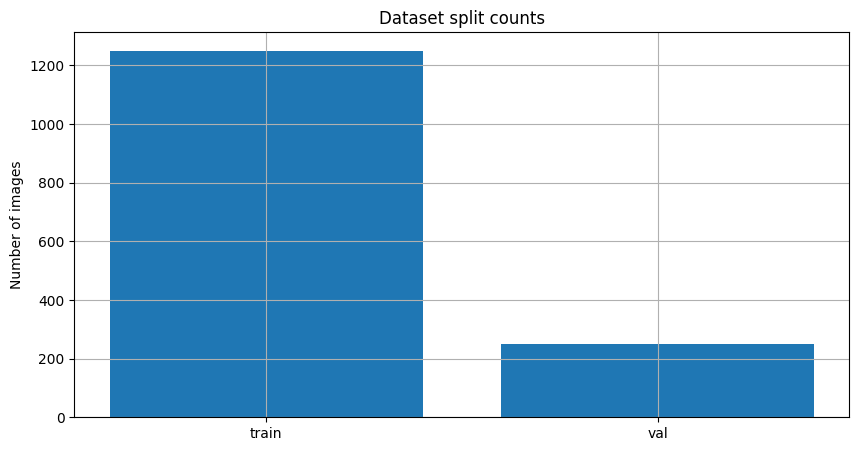

In [6]:
counts = df["split"].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title("Dataset split counts")
ax.set_ylabel("Number of images")
plt.show()


## 3. Annotation integrity checks

Before studying distributions, we verify that the data package is internally consistent. We check:
- image counts against metadata rows
- annotation counts against image counts
- missing values
- duplicate file names
- basic bounding-box validity

A clean integrity report is useful in the paper because it demonstrates that the dataset is reproducible and organized well enough for model development.


In [7]:
def extract_counts(coco):
    return len(coco["images"]), len(coco["annotations"])

train_img_count_coco, train_ann_count_coco = extract_counts(train_coco)
val_img_count_coco, val_ann_count_coco = extract_counts(val_coco)

integrity = {
    "train_metadata_rows": len(train_meta),
    "val_metadata_rows": len(val_meta),
    "train_coco_images": train_img_count_coco,
    "val_coco_images": val_img_count_coco,
    "train_coco_annotations": train_ann_count_coco,
    "val_coco_annotations": val_ann_count_coco,
    "missing_values_total": int(df.isna().sum().sum()),
    "duplicate_file_names": int(df["file_name"].duplicated().sum()),
    "invalid_bbox_widths": int((df["bbox_w"] <= 0).sum()),
    "invalid_bbox_heights": int((df["bbox_h"] <= 0).sum()),
    "bbox_outside_left": int((df["bbox_x"] < 0).sum()),
    "bbox_outside_top": int((df["bbox_y"] < 0).sum()),
    "bbox_outside_right": int(((df["bbox_x"] + df["bbox_w"]) > 384).sum()),
    "bbox_outside_bottom": int(((df["bbox_y"] + df["bbox_h"]) > 256).sum()),
}
pd.DataFrame(list(integrity.items()), columns=["check", "value"])


,check,value
0,train_metadata_rows,1250
1,val_metadata_rows,250
2,train_coco_images,1250
3,val_coco_images,250
4,train_coco_annotations,1250
5,val_coco_annotations,250
6,missing_values_total,0
7,duplicate_file_names,0
8,invalid_bbox_widths,0
9,invalid_bbox_heights,0


## 4. Summary statistics for the regression targets

The Cubify vision module ultimately needs to infer parcel geometry accurately enough to support downstream optimization. For that reason, the physical targets themselves deserve a detailed statistical summary:
- **length**
- **width**
- **height**
- **derived volume**

This section helps define the target space the model must learn.


In [8]:
numeric_cols = ["length_cm", "width_cm", "height_cm", "volume_cm3", "bbox_fill_ratio"]
summary_stats = df[numeric_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
summary_stats


,mean,std,min,25%,50%,75%,max
length_cm,55.31,21.40,18.0,37.00,56.00,74.00,90.00
width_cm,40.69,16.69,12.0,26.00,40.00,55.00,70.00
height_cm,33.90,15.01,8.0,21.00,34.00,47.00,60.00
volume_cm3,77020.89,61361.82,3344.0,31596.00,59136.00,104566.00,335104.00
bbox_fill_ratio,0.06,0.04,0.0,0.03,0.05,0.08,0.31


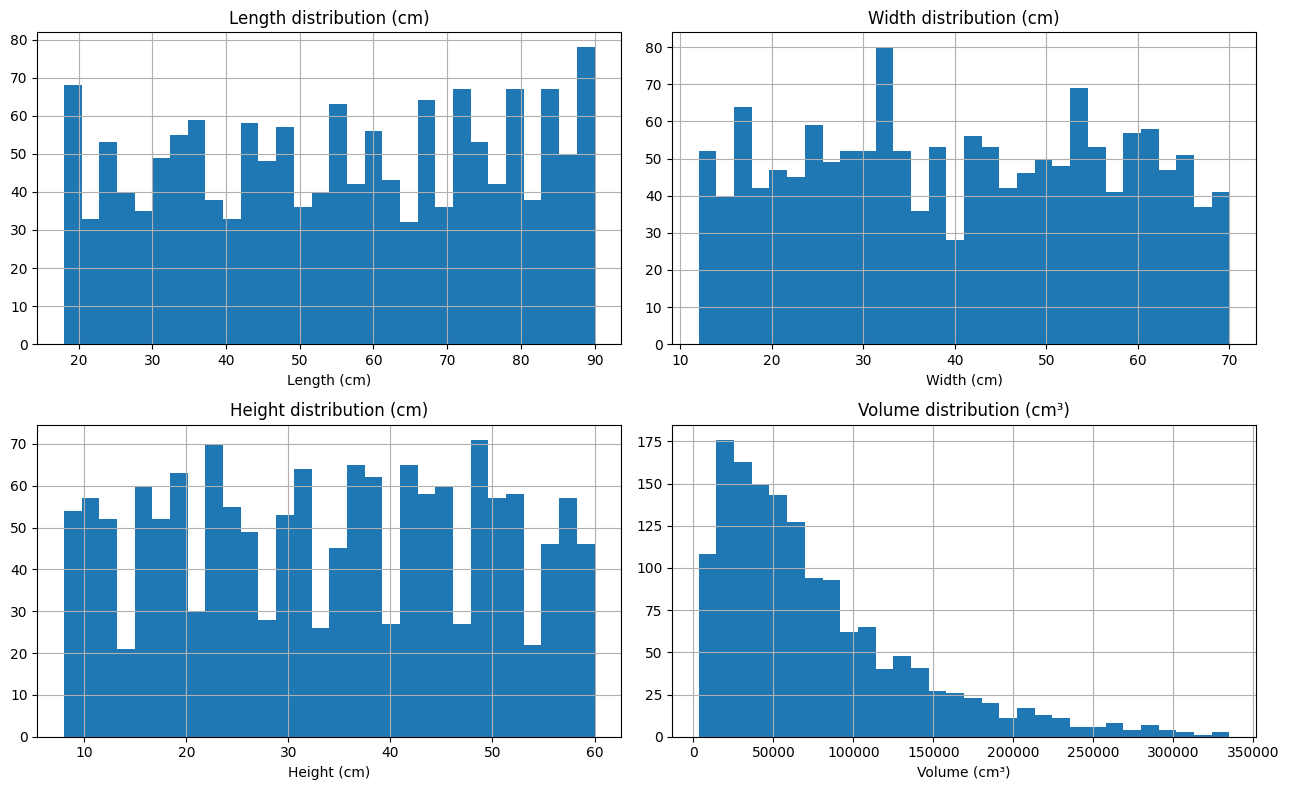

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(df["length_cm"], bins=30)
axes[0, 0].set_title("Length distribution (cm)")
axes[0, 0].set_xlabel("Length (cm)")

axes[0, 1].hist(df["width_cm"], bins=30)
axes[0, 1].set_title("Width distribution (cm)")
axes[0, 1].set_xlabel("Width (cm)")

axes[1, 0].hist(df["height_cm"], bins=30)
axes[1, 0].set_title("Height distribution (cm)")
axes[1, 0].set_xlabel("Height (cm)")

axes[1, 1].hist(df["volume_cm3"], bins=30)
axes[1, 1].set_title("Volume distribution (cm³)")
axes[1, 1].set_xlabel("Volume (cm³)")

plt.tight_layout()
plt.show()


### Research note

A wide spread in physical dimensions is desirable because the warehouse problem involves mixed parcel sizes, not a narrow single-SKU environment. At the same time, the distributions should still look operationally plausible. We therefore inspect quantiles next.


In [10]:
quantiles = df[numeric_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(2)
quantiles


,length_cm,width_cm,height_cm,volume_cm3,bbox_fill_ratio
0.05,21.0,15.0,10.00,12166.8,0.01
0.25,37.0,26.0,21.00,31596.0,0.03
0.50,56.0,40.0,34.00,59136.0,0.05
0.75,74.0,55.0,47.00,104566.0,0.08
0.95,88.0,67.0,57.05,207918.9,0.15


## 5. Parcel shape diversity

Absolute dimensions are only part of the story. For learning-based dimension estimation, **shape diversity** matters because two parcels can have similar volume while presenting very different silhouettes. We examine a few simple ratios:
- length / width
- width / height
- length / height

These ratios help us understand whether the dataset includes mostly near-cubical boxes or also elongated and flatter shapes.


In [11]:
ratio_cols = ["length_to_width", "width_to_height", "length_to_height"]
df[ratio_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)


,mean,std,min,25%,50%,75%,max
length_to_width,1.70,1.19,0.26,0.90,1.35,2.11,7.33
width_to_height,1.59,1.27,0.22,0.76,1.21,1.90,8.62
length_to_height,2.16,1.71,0.30,1.07,1.64,2.60,11.12


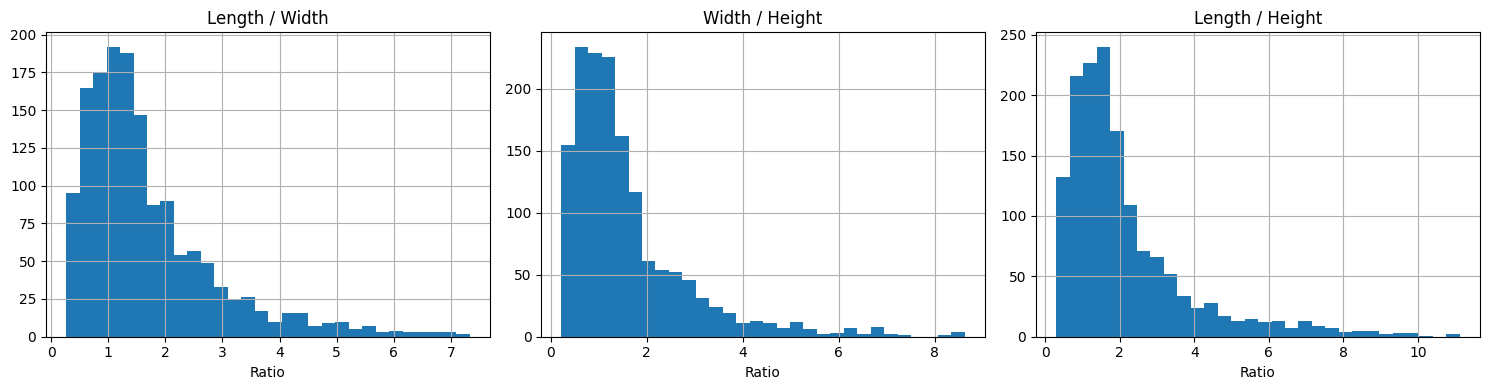

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ratio_cols,
    ["Length / Width", "Width / Height", "Length / Height"]
):
    ax.hist(df[col], bins=30)
    ax.set_title(title)
    ax.set_xlabel("Ratio")
plt.tight_layout()
plt.show()


In [13]:
shape_family = pd.cut(
    df["length_to_height"],
    bins=[0, 1.25, 2.0, 3.0, np.inf],
    labels=["near-cube", "moderately elongated", "elongated", "highly elongated"]
)
shape_family.value_counts().sort_index().rename_axis("shape_family").to_frame("count")


,count
shape_family,
near-cube,500
moderately elongated,451
elongated,251
highly elongated,298


## 6. Projected 2D footprint and annotation geometry

The model will learn from image appearance, but the supervisory signal is also strongly tied to the 2D projected box geometry. This section studies:
- bounding-box widths and heights
- percentage of image area occupied by the parcel
- spatial concentration of boxes in the frame

These characteristics influence training difficulty. Very small projected boxes tend to be harder than medium-sized or large ones, while strong spatial bias may artificially simplify learning.


In [14]:
bbox_summary = df[["bbox_w", "bbox_h", "bbox_area_px", "bbox_fill_ratio", "bbox_center_x", "bbox_center_y"]].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)
bbox_summary


,mean,std,min,25%,50%,75%,max
bbox_w,115.28,41.85,31.99,83.63,110.99,144.45,254.37
bbox_h,49.16,21.92,8.84,32.39,46.36,63.71,126.33
bbox_area_px,5996.98,4173.25,446.94,2959.16,4895.02,7809.98,30574.39
bbox_fill_ratio,0.06,0.04,0.00,0.03,0.05,0.08,0.31
bbox_center_x,193.78,67.44,47.54,138.32,194.80,251.70,344.94
bbox_center_y,201.09,15.52,146.23,192.18,202.32,211.34,237.60


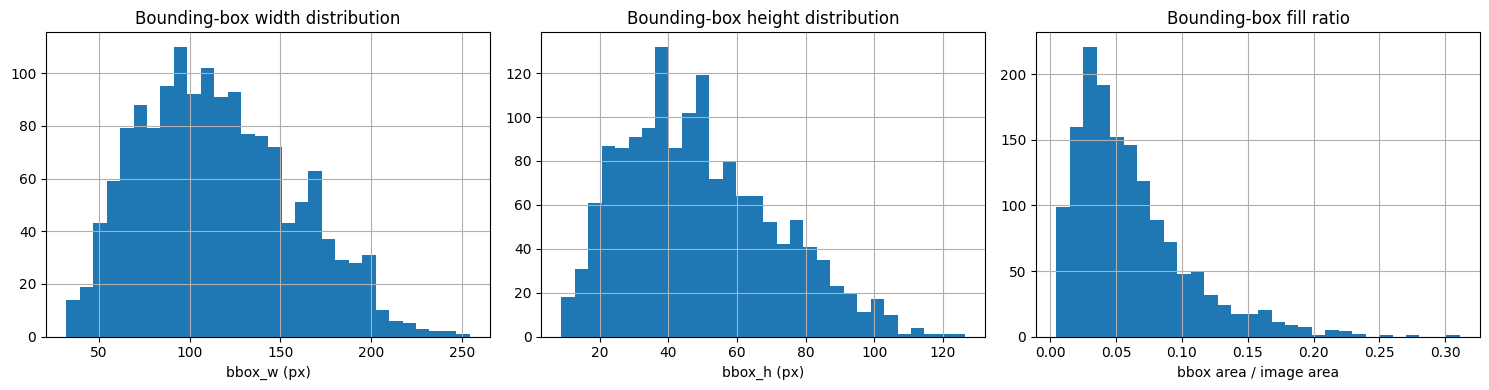

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["bbox_w"], bins=30)
axes[0].set_title("Bounding-box width distribution")
axes[0].set_xlabel("bbox_w (px)")

axes[1].hist(df["bbox_h"], bins=30)
axes[1].set_title("Bounding-box height distribution")
axes[1].set_xlabel("bbox_h (px)")

axes[2].hist(df["bbox_fill_ratio"], bins=30)
axes[2].set_title("Bounding-box fill ratio")
axes[2].set_xlabel("bbox area / image area")

plt.tight_layout()
plt.show()


A heatmap of bounding-box centers is particularly useful. If boxes always appear at nearly the same place, the task becomes easier but also less realistic. If centers spread more broadly, the synthetic generation process is producing better positional diversity.


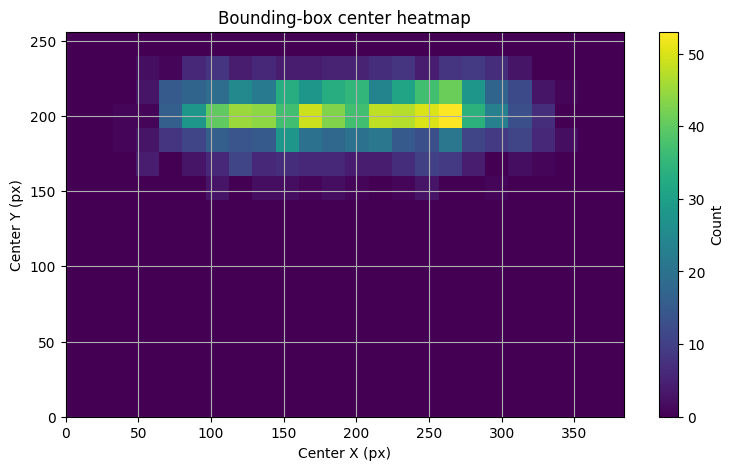

In [16]:
heatmap, xedges, yedges = np.histogram2d(
    df["bbox_center_x"],
    df["bbox_center_y"],
    bins=(24, 16),
    range=[[0, 384], [0, 256]]
)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    heatmap.T,
    origin="lower",
    extent=[0, 384, 0, 256],
    aspect="auto"
)
ax.set_title("Bounding-box center heatmap")
ax.set_xlabel("Center X (px)")
ax.set_ylabel("Center Y (px)")
plt.colorbar(im, ax=ax, label="Count")
plt.show()


## 7. Correlation structure

A dimensioning model benefits when the dataset preserves a meaningful relationship between real-world parcel geometry and projected 2D cues. We therefore study the correlation between:
- physical dimensions
- projected bounding-box dimensions
- projected area
- volume

High correlation does not guarantee learnability, but it does indicate that the synthetic generator encodes visually useful geometric signals.


In [17]:
corr_cols = [
    "length_cm", "width_cm", "height_cm",
    "volume_cm3", "bbox_w", "bbox_h",
    "bbox_area_px", "bbox_fill_ratio"
]
corr = df[corr_cols].corr().round(3)
corr


,length_cm,width_cm,height_cm,volume_cm3,bbox_w,bbox_h,bbox_area_px,bbox_fill_ratio
length_cm,1.000,0.022,0.025,0.515,0.781,0.070,0.448,0.448
width_cm,0.022,1.000,0.007,0.535,0.308,0.140,0.250,0.250
height_cm,0.025,0.007,1.000,0.569,0.057,0.826,0.554,0.554
volume_cm3,0.515,0.535,0.569,1.000,0.583,0.572,0.720,0.720
bbox_w,0.781,0.308,0.057,0.583,1.000,0.360,0.758,0.758
bbox_h,0.070,0.140,0.826,0.572,0.360,1.000,0.838,0.838
bbox_area_px,0.448,0.250,0.554,0.720,0.758,0.838,1.000,1.000
bbox_fill_ratio,0.448,0.250,0.554,0.720,0.758,0.838,1.000,1.000


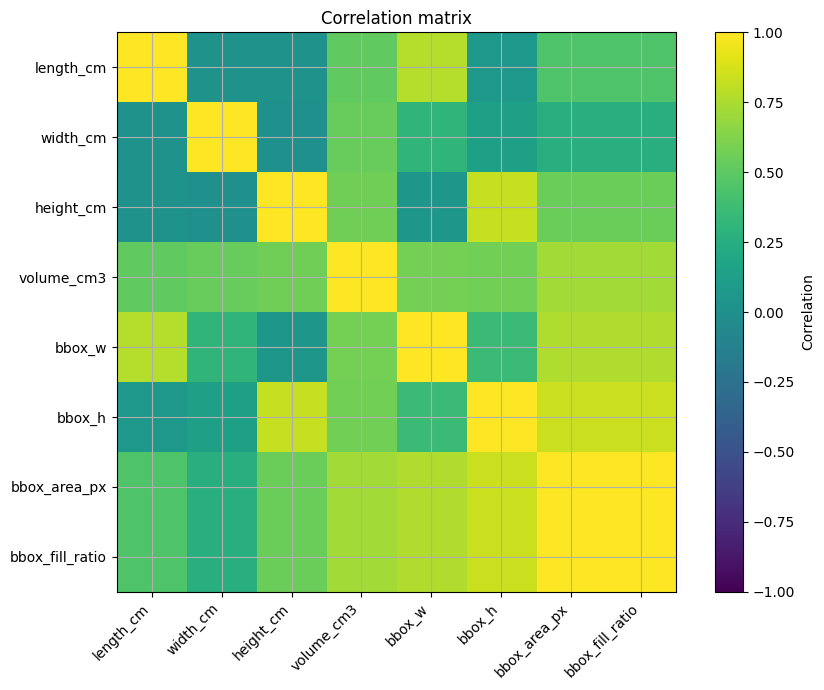

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


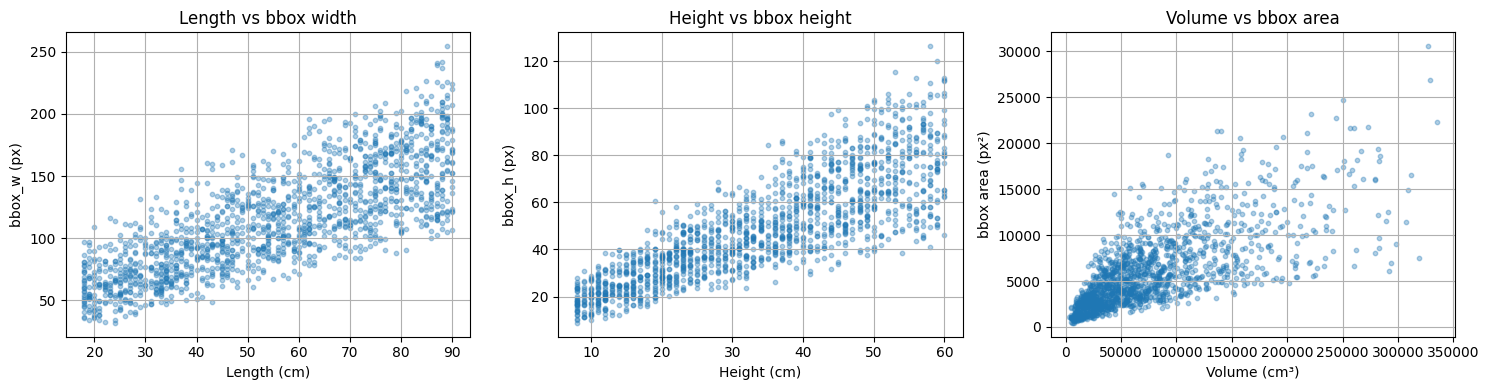

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["length_cm"], df["bbox_w"], alpha=0.35, s=10)
axes[0].set_title("Length vs bbox width")
axes[0].set_xlabel("Length (cm)")
axes[0].set_ylabel("bbox_w (px)")

axes[1].scatter(df["height_cm"], df["bbox_h"], alpha=0.35, s=10)
axes[1].set_title("Height vs bbox height")
axes[1].set_xlabel("Height (cm)")
axes[1].set_ylabel("bbox_h (px)")

axes[2].scatter(df["volume_cm3"], df["bbox_area_px"], alpha=0.35, s=10)
axes[2].set_title("Volume vs bbox area")
axes[2].set_xlabel("Volume (cm³)")
axes[2].set_ylabel("bbox area (px²)")

plt.tight_layout()
plt.show()


## 8. Image-level quality proxies

Even in synthetic data, image quality matters. We compute two lightweight proxies:
- **brightness**: mean grayscale intensity
- **sharpness proxy**: variance of image gradients

These do not replace a full image quality audit, but they help assess whether the dataset includes meaningful photometric and blur variation.


In [20]:
def image_metrics(path):
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.float32)
    brightness = arr.mean()
    gy, gx = np.gradient(arr)
    sharpness = gx.var() + gy.var()
    return brightness, sharpness

rows = []
for split, img_dir in [("train", TRAIN_IMG_DIR), ("val", VAL_IMG_DIR)]:
    for path in sorted(img_dir.glob("*.jpg")):
        brightness, sharpness = image_metrics(path)
        rows.append((path.name, split, brightness, sharpness))

img_df = pd.DataFrame(rows, columns=["file_name", "split", "brightness", "sharpness"])
img_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)


,mean,std,min,25%,50%,75%,max
brightness,54.61,9.12,36.54,47.20,54.47,61.06,87.24
sharpness,59.55,25.01,10.82,40.44,57.35,77.00,145.58


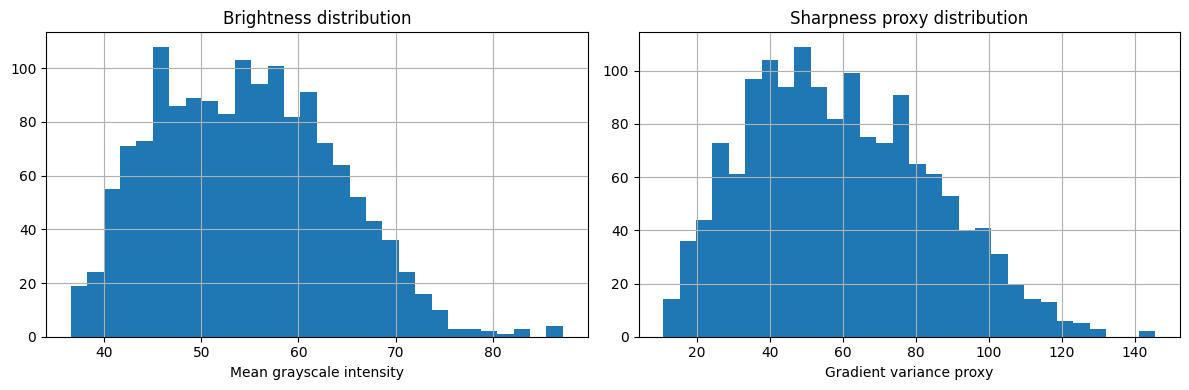

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_df["brightness"], bins=30)
axes[0].set_title("Brightness distribution")
axes[0].set_xlabel("Mean grayscale intensity")

axes[1].hist(img_df["sharpness"], bins=30)
axes[1].set_title("Sharpness proxy distribution")
axes[1].set_xlabel("Gradient variance proxy")

plt.tight_layout()
plt.show()


## 9. Visual audit of sample images

A visual audit is essential in synthetic-data projects. It allows us to confirm that:
- box appearance is plausible
- label and tape textures vary
- the projected bounding box matches the visible parcel
- scene composition is not trivially repetitive

The next cell displays a small grid of samples with overlayed metadata.


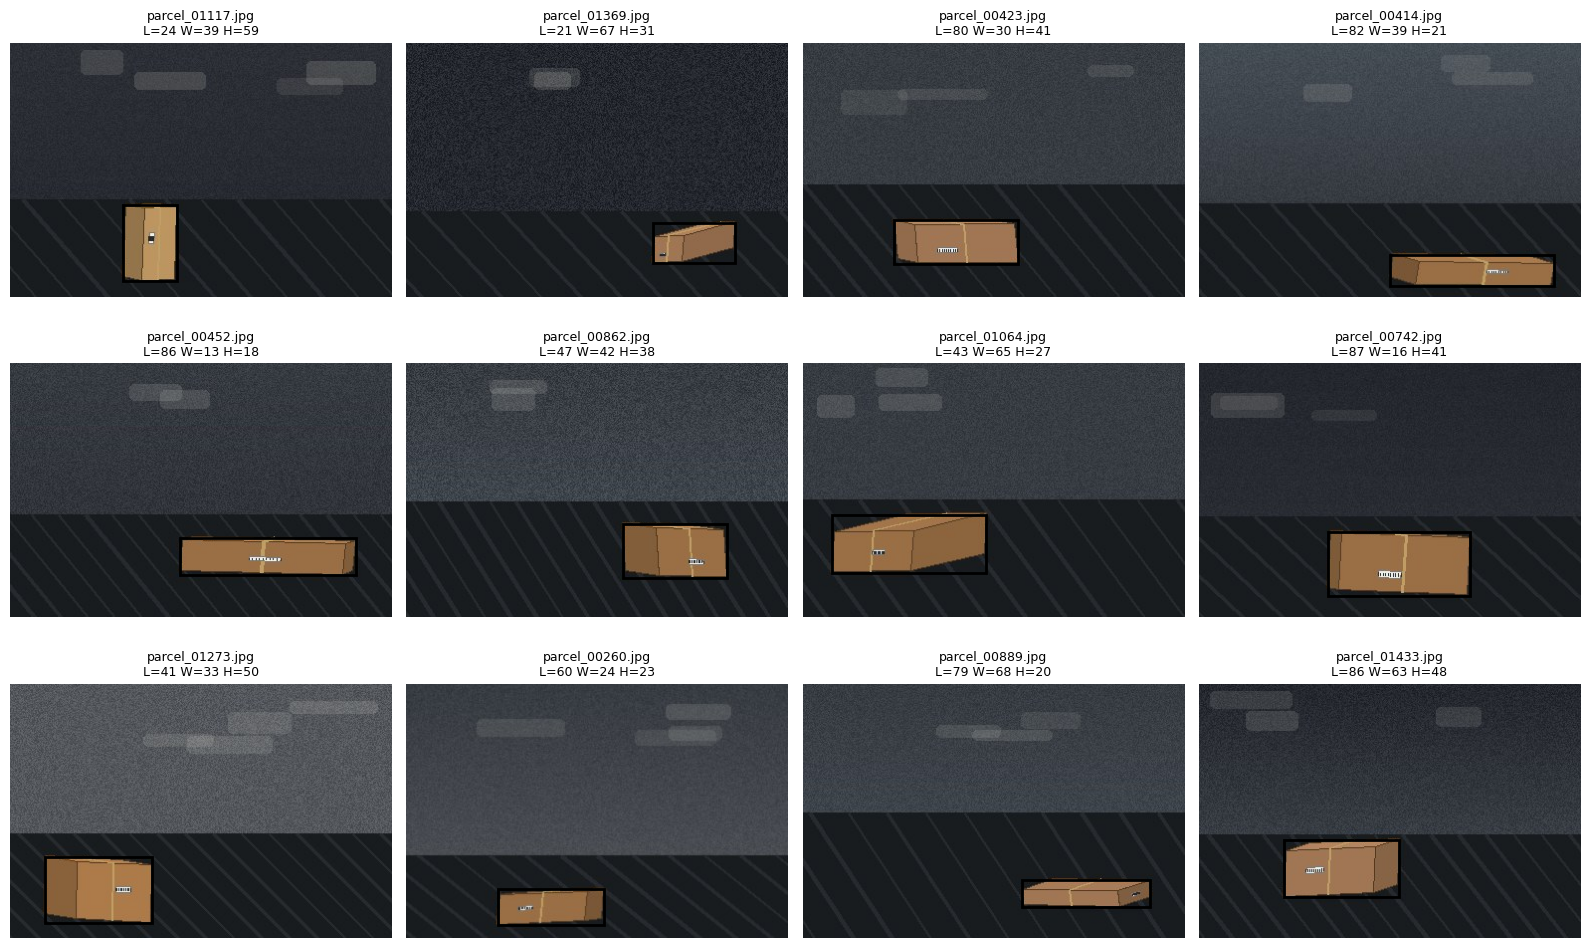

In [22]:
sample_df = df.sample(12, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, row in zip(axes.ravel(), sample_df.itertuples(index=False)):
    img_path = (TRAIN_IMG_DIR if row.split == "train" else VAL_IMG_DIR) / row.file_name
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    rect = plt.Rectangle((row.bbox_x, row.bbox_y), row.bbox_w, row.bbox_h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.set_title(
        f"{row.file_name}\nL={row.length_cm} W={row.width_cm} H={row.height_cm}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 10. Train/validation split comparability

A useful validation split should be similar enough to the training split to support fair model selection, but not so narrow that it hides generalization risk. Here we compare the principal target variables between train and validation.


In [23]:
split_compare = df.groupby("split")[["length_cm", "width_cm", "height_cm", "volume_cm3", "bbox_fill_ratio"]].agg(
    ["mean", "median", "std"]
).round(2)
split_compare


length_cm               width_cm               height_cm                \
           mean median    std     mean median    std      mean median    std   
split                                                                          
train     55.24   55.0  21.32    40.66   40.0  16.69     33.85   34.0  14.96   
val       55.65   58.0  21.83    40.84   40.5  16.75     34.18   33.0  15.26   

      volume_cm3                    bbox_fill_ratio               
            mean   median       std            mean median   std  
split                                                             
train   76789.94  58884.0  60968.55            0.06   0.05  0.04  
val     78175.68  59340.0  63404.30            0.06   0.05  0.04

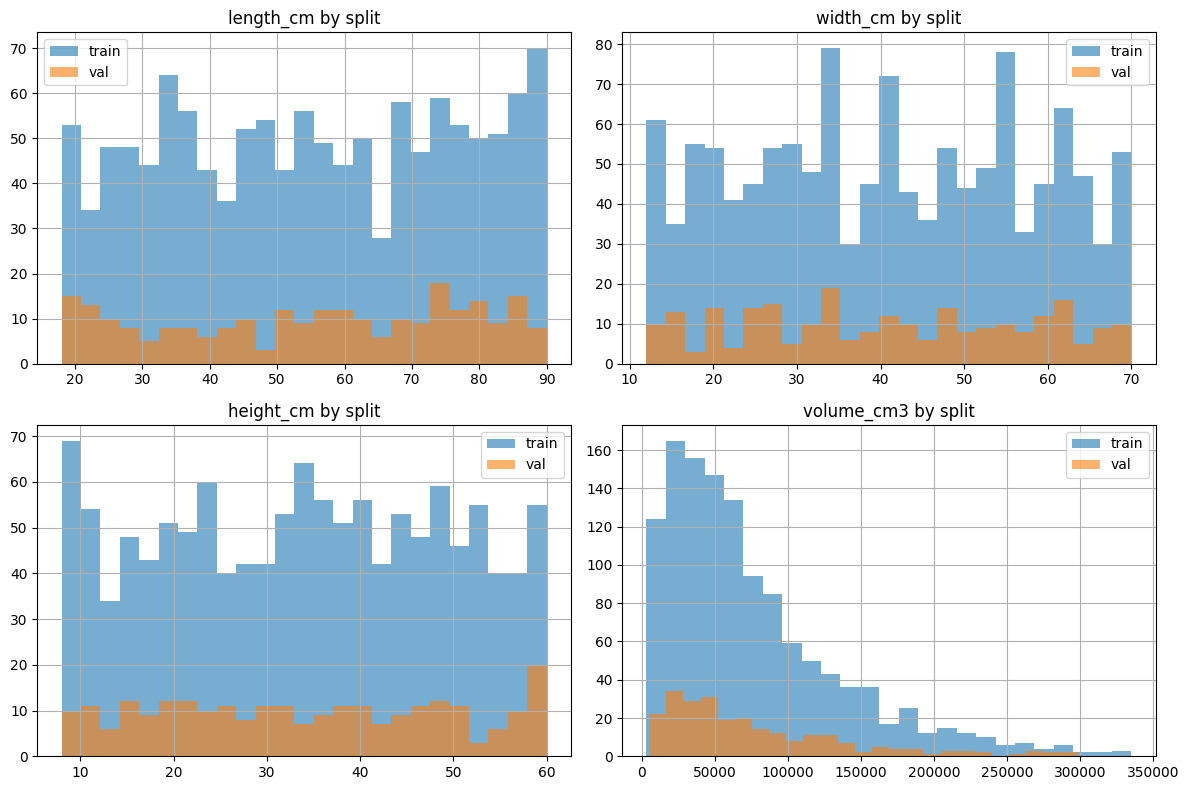

In [24]:
cols = ["length_cm", "width_cm", "height_cm", "volume_cm3"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), cols):
    train_vals = df.loc[df["split"] == "train", col].values
    val_vals = df.loc[df["split"] == "val", col].values
    bins = 25
    ax.hist(train_vals, bins=bins, alpha=0.6, label="train")
    ax.hist(val_vals, bins=bins, alpha=0.6, label="val")
    ax.set_title(f"{col} by split")
    ax.legend()

plt.tight_layout()
plt.show()


## 11. Outliers and edge cases

Outlier analysis matters for two reasons:
1. It reveals whether the dataset contains challenging samples that may be informative for model robustness.
2. It helps the paper distinguish between *true edge cases* and *annotation anomalies*.

We use a simple IQR rule on the main numeric variables.


In [25]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_rows = []
for col in ["length_cm", "width_cm", "height_cm", "volume_cm3", "bbox_fill_ratio"]:
    lo, hi = iqr_bounds(df[col])
    count = int(((df[col] < lo) | (df[col] > hi)).sum())
    outlier_rows.append({"variable": col, "lower_bound": round(lo, 2), "upper_bound": round(hi, 2), "outlier_count": count})

outlier_df = pd.DataFrame(outlier_rows)
outlier_df


,variable,lower_bound,upper_bound,outlier_count
0,length_cm,-18.50,129.50,0
1,width_cm,-17.50,98.50,0
2,height_cm,-18.00,86.00,0
3,volume_cm3,-77859.00,214021.00,66
4,bbox_fill_ratio,-0.04,0.15,73


In [26]:
# Show the largest-volume samples, which are operationally important because they often stress both
# dimensioning and downstream storage assignment.
edge_cases = df.sort_values("volume_cm3", ascending=False).head(12)[
    ["split", "file_name", "length_cm", "width_cm", "height_cm", "volume_cm3", "bbox_fill_ratio"]
].reset_index(drop=True)
edge_cases


,split,file_name,length_cm,width_cm,height_cm,volume_cm3,bbox_fill_ratio
0,train,parcel_00067.jpg,88,68,56,335104,0.226534
1,train,parcel_00437.jpg,90,62,59,329220,0.274030
2,train,parcel_01164.jpg,88,64,58,326656,0.311019
3,train,parcel_00931.jpg,86,64,58,319232,0.076095
4,train,parcel_00686.jpg,88,59,60,311520,0.168856
5,train,parcel_01052.jpg,76,70,58,308560,0.151845
6,train,parcel_00471.jpg,84,63,58,306936,0.116559
7,val,parcel_01325.jpg,90,65,51,298350,0.092404
8,train,parcel_00272.jpg,88,68,49,293216,0.070998
9,val,parcel_01398.jpg,74,68,58,291856,0.061675


## 12. Findings and implications

This section translates the exploratory results into a compact narrative suitable for reuse in the Cubify paper.

### Key findings

- The dataset contains **1,500 synthetic parcel images** split into **1,250 training** and **250 validation** samples, which gives an **83.3% / 16.7%** split suitable for early proof-of-concept experimentation.
- Parcel dimensions span a broad range. In this synthetic set, the central tendency is approximately:
  - mean length: **55.31 cm**
  - mean width: **40.69 cm**
  - mean height: **33.90 cm**
  - median volume: **59,136 cm³**
- The target space is intentionally heterogeneous, which is useful for learning a general parcel-dimensioning model rather than a narrow single-product estimator.
- The projected object footprint is also diverse. The mean bounding-box fill ratio is about **6.10%** of image area, with a range from roughly **0.45%** to **31.10%**. This suggests the model will encounter both small and large projected parcels, which is beneficial for robustness.
- Annotation integrity checks show a clean dataset package with no missing values, no duplicate file names, and valid positive bounding-box widths and heights.
- Correlation analysis indicates that projected image geometry carries usable information about real-world targets:
  - correlation between length and bounding-box width is about **0.78**
  - correlation between height and bounding-box height is about **0.83**
  - correlation between volume and projected bounding-box area is about **0.72**
  These values support the assumption that visual cues in the synthetic images are meaningfully aligned with the regression targets.
- Train and validation distributions are very similar across the main variables, which suggests the current split is appropriate for early model development and hyperparameter selection.

### Interpretation for the Cubify paper

From a research perspective, the synthetic dataset appears suitable for **initial model development, sanity checking, and ablation studies** for the vision module. The dataset offers:
- sufficient variation in parcel dimensions,
- sufficient variation in projected size and position,
- low annotation noise,
- and moderate image-level variation in brightness and blur.

These properties make it appropriate for building and benchmarking a first computer-vision dimensioning pipeline before introducing real-world fine-tuning data.

### Important limitation

This EDA also reinforces a major limitation that should be stated clearly in the paper: **synthetic-only EDA cannot establish sim-to-real generalization**. The dataset is internally consistent and visually varied, but it still does not capture the full complexity of production warehouse conditions such as:
- conveyor vibration,
- motion blur from real camera exposure settings,
- damaged cartons,
- irregular packaging,
- reflective plastic wrap,
- partial occlusions from neighboring items,
- and camera calibration drift.

Accordingly, the correct claim is that this synthetic dataset is well suited for **prototype training and controlled experimentation**, not for final production-readiness claims on its own.


## 13. Recommended next analytical steps

Based on this EDA, the next technical steps would be:

1. **Baseline regression experiments** using the synthetic set only.
2. **Ablation studies** comparing direct dimension regression versus multi-head prediction from the same backbone.
3. **Data augmentation experiments** to increase robustness to blur, brightness changes, and scale shifts.
4. **Error analysis by parcel size regime** so the team can report whether large, medium, and small parcels behave differently.
5. **Synthetic-to-real transfer experiments** once real conveyor data is available.

This notebook therefore serves as the dataset-analysis foundation for the next stage: model training and validation.
